# Numeric Inference: Predicting Video Popularity from Title Embeddings

This notebook explores the predictive power of video title embeddings for estimating video views. We train per-channel linear regression models using low-dimensional semantic representations.

## 1. Setup and Configuration

Install necessary libraries and mount Google Drive.

In [67]:
!pip install -q sentence-transformers scikit-learn pandas numpy matplotlib seaborn statsmodels

import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sentence_transformers import SentenceTransformer

try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print('Not running in Colab or drive mount failed.')

# Configuration
CONFIG = {
    'INPUT_PATH': '/content/drive/MyDrive/Graphiko/exports/base_data/latest/channels_structured.json',
    'OUTPUT_DIR': '/content/drive/MyDrive/numeric_inference_outputs',
    'EMBEDDING_MODEL_NAME': 'all-MiniLM-L6-v2',
    'GLOBAL_PCA_COMPONENTS': 15,
    'LOCAL_PCA_COMPONENTS': 5,
    'MIN_VIDEOS_PER_CHANNEL': 40,
    'REUSE_CACHE': True
}

if not os.path.exists(CONFIG['OUTPUT_DIR']):
    os.makedirs(CONFIG['OUTPUT_DIR'], exist_ok=True)

embedding_model = SentenceTransformer(CONFIG['EMBEDDING_MODEL_NAME'])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

## 2. Data Loading and Filtering

Load the structured channel data and filter for channels with at least 40 videos.

In [68]:
def load_and_filter_data(file_path):
    if not os.path.exists(file_path):
        print(f'Error: File not found at {file_path}')
        return []

    with open(file_path, 'r') as f:
        data = json.load(f)

    filtered_data = [channel for channel in data if len(channel['videos']) >= CONFIG['MIN_VIDEOS_PER_CHANNEL']]

    print(f'Original channels: {len(data)}')
    print(f'Filtered channels (>= {CONFIG["MIN_VIDEOS_PER_CHANNEL"]} videos): {len(filtered_data)}')

    return filtered_data

channels = load_and_filter_data(CONFIG['INPUT_PATH'])

Original channels: 27
Filtered channels (>= 40 videos): 27


## 3. Embedding Video Titles

Embed all video titles using the specified model. We cache embeddings to Google Drive to avoid redundant computations.

In [69]:
def get_embedding_cache_path():
    return os.path.join(CONFIG['OUTPUT_DIR'], 'video_title_embeddings_latest.json')

def load_embedding_cache():
    path = get_embedding_cache_path()
    if CONFIG['REUSE_CACHE'] and os.path.exists(path):
        with open(path, 'r') as f:
            return json.load(f)
    return {}

def save_embedding_cache(cache):
    path = get_embedding_cache_path()
    with open(path, 'w') as f:
        json.dump(cache, f)

    # Versioned copy
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    versioned_path = os.path.join(CONFIG['OUTPUT_DIR'], f'video_title_embeddings_{timestamp}.json')
    with open(versioned_path, 'w') as f:
        json.dump(cache, f)

embedding_cache = load_embedding_cache()

def embed_titles(channels_data):
    all_titles = []
    for channel in channels_data:
        for video in channel['videos']:
            if video['title'] not in embedding_cache:
                all_titles.append(video['title'])

    if all_titles:
        print(f'Embedding {len(all_titles)} new titles...')
        new_embeddings = embedding_model.encode(all_titles, show_progress_bar=True)
        for title, emb in zip(all_titles, new_embeddings):
            embedding_cache[title] = emb.tolist()
        save_embedding_cache(embedding_cache)
    else:
        print('All titles already embedded and cached.')

if channels:
    embed_titles(channels)

All titles already embedded and cached.


## 4. Data Splitting

Split the data into 80% training and 20% testing per channel. Save both files in Google drive, and document both paths.

In [70]:
train_data = []
test_data = []

for channel in channels:
    videos = channel['videos']
    train_vids, test_vids = train_test_split(videos, test_size=0.2, random_state=42)

    train_data.append({
        'channel_id': channel['channel_id'],
        'channel_name': channel['channel_name'],
        'videos': train_vids
    })

    test_data.append({
        'channel_id': channel['channel_id'],
        'channel_name': channel['channel_name'],
        'videos': test_vids
    })

# Save splits
train_path = os.path.join(CONFIG['OUTPUT_DIR'], 'train_structured_latest.json')
test_path = os.path.join(CONFIG['OUTPUT_DIR'], 'test_structured_latest.json')

with open(train_path, 'w') as f:
    json.dump(train_data, f, indent=2)
with open(test_path, 'w') as f:
    json.dump(test_data, f, indent=2)

# Versioned copies
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
save_path_train = os.path.join(CONFIG['OUTPUT_DIR'], f'train_structured_{timestamp}.json')
save_path_test = os.path.join(CONFIG['OUTPUT_DIR'], f'test_structured_{timestamp}.json')

with open(save_path_train, 'w') as f:
    json.dump(train_data, f, indent=2)
with open(save_path_test, 'w') as f:
    json.dump(test_data, f, indent=2)

print(f'Training split saved to: {train_path} (and {save_path_train})')
print(f'Testing split saved to: {test_path} (and {save_path_test})')

Training split saved to: /content/drive/MyDrive/numeric_inference_outputs/train_structured_latest.json (and /content/drive/MyDrive/numeric_inference_outputs/train_structured_20260614_182806.json)
Testing split saved to: /content/drive/MyDrive/numeric_inference_outputs/test_structured_latest.json (and /content/drive/MyDrive/numeric_inference_outputs/test_structured_20260614_182806.json)


## 5. Dimensionality Reduction (PCA)

Reduce the embedding dimensionality to 20 using PCA, fitted on the entire training set.

In [71]:
def get_all_embeddings(data_split):
    embeddings = []
    for channel in data_split:
        for video in channel['videos']:
            embeddings.append(embedding_cache[video['title']])
    return np.array(embeddings)

train_embeddings = get_all_embeddings(train_data)
test_embeddings = get_all_embeddings(test_data)

print(f'Train embeddings shape: {train_embeddings.shape}')
print(f'Test embeddings shape: {test_embeddings.shape}')

pca = PCA(n_components=CONFIG['PCA_COMPONENTS'], random_state=42)
train_pca = pca.fit_transform(train_embeddings)
test_pca = pca.transform(test_embeddings)

print(f'Train PCA shape: {train_pca.shape}')
print(f'Test PCA shape: {test_pca.shape}')
print(f'Explained variance ratio: {pca.explained_variance_ratio_.sum():.4f}')

Train embeddings shape: (1075, 384)
Test embeddings shape: (269, 384)
Train PCA shape: (1075, 15)
Test PCA shape: (269, 15)
Explained variance ratio: 0.3233


def get_all_embeddings(data_split):
    embeddings = []
    for channel in data_split:
        for video in channel['videos']:
            embeddings.append(embedding_cache[video['title']])
    return np.array(embeddings)

train_embeddings = get_all_embeddings(train_data)
test_embeddings = get_all_embeddings(test_data)

print(f'Train embeddings shape: {train_embeddings.shape}')
print(f'Test embeddings shape: {test_embeddings.shape}')

pca = PCA(n_components=CONFIG['GLOBAL_PCA_COMPONENTS'], random_state=42)
train_pca = pca.fit_transform(train_embeddings)
test_pca = pca.transform(test_embeddings)

print(f'Train PCA shape: {train_pca.shape}')
print(f'Test PCA shape: {test_pca.shape}')
print(f'Explained variance ratio: {pca.explained_variance_ratio_.sum():.4f}')

In [72]:
channel_models = {}
training_summaries = []

current_train_idx = 0

for channel in train_data:
    num_videos = len(channel['videos'])
    channel_train_pca = train_pca[current_train_idx : current_train_idx + num_videos]

    # Get log views
    views = [v['views'] for v in channel['videos']]
    # Use log1p to handle zero views if any, though unlikely for filtered channels
    log_views = np.log1p(views)

    model = LinearRegression()
    model.fit(channel_train_pca, log_views)

    train_preds = model.predict(channel_train_pca)
    train_r2 = r2_score(log_views, train_preds)
    train_mae = mean_absolute_error(log_views, train_preds)

    channel_models[channel['channel_id']] = model

    training_summaries.append({
        'channel_name': channel['channel_name'],
        'num_videos': num_videos,
        'train_r2': train_r2,
        'train_mae': train_mae
    })

    current_train_idx += num_videos

df_train_summary = pd.DataFrame(training_summaries)
print('Training Summary (Top 10 Channels by R2):')
display(df_train_summary.sort_values('train_r2', ascending=False).head(10))

print(f'Mean Training R2: {df_train_summary["train_r2"].mean():.4f}')
print(f'Mean Training MAE (log scale): {df_train_summary["train_mae"].mean():.4f}')

Training Summary (Top 10 Channels by R2):


,channel_name,num_videos,train_r2,train_mae
7,Real Vision Presents,40,0.846771,0.656236
17,Alex Hormozi,40,0.719097,0.370672
13,ARK Invest,40,0.646895,0.708433
9,Garry Tan,40,0.628048,0.380276
14,Network State Podcast,40,0.624464,0.601973
5,Dan Martell,40,0.619134,0.373057
6,Patrick Boyle,40,0.588411,0.321385
22,This Week in Startups,40,0.575868,0.594820
0,Bg2 Pod,35,0.568937,0.353507
2,Asianometry,40,0.543369,0.299993


Mean Training R2: 0.4896
Mean Training MAE (log scale): 0.5220


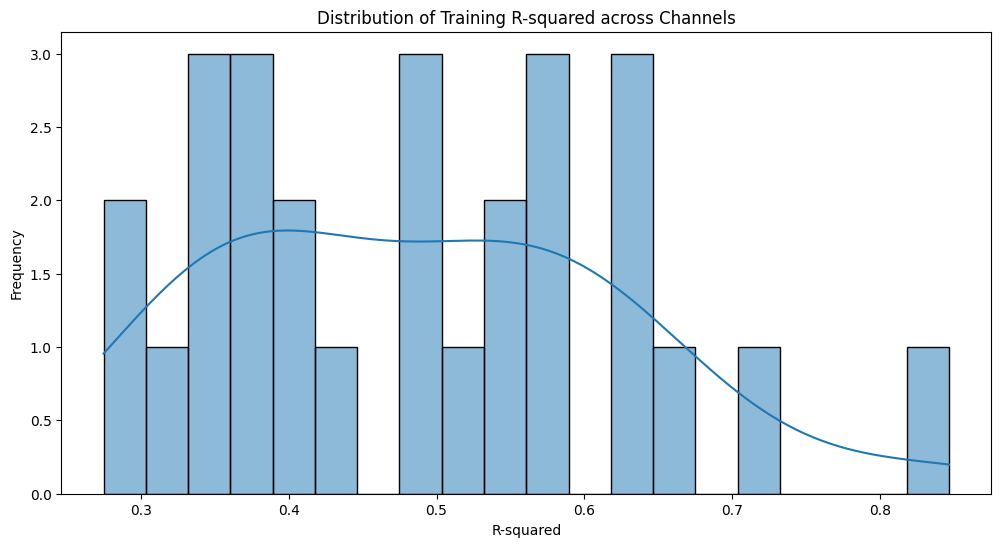

In [73]:
## 6. Model Training: Hierarchical/Mixed-Effects styled Approach

# 1. Prepare Global Training Data
all_train_log_views = []
for channel in train_data:
    views = [v['views'] for v in channel['videos']]
    all_train_log_views.extend(np.log1p(views))

all_train_log_views = np.array(all_train_log_views)

# 2. Global Normalization
GLOBAL_MEAN = all_train_log_views.mean()
GLOBAL_STD = all_train_log_views.std()

print(f'Global Mean (log views): {GLOBAL_MEAN:.4f}')
print(f'Global Std (log views): {GLOBAL_STD:.4f}')

norm_train_log_views = (all_train_log_views - GLOBAL_MEAN) / GLOBAL_STD

# 3. Train Global Model for Feature Selection
# Add constant for intercept
X_global = sm.add_constant(train_pca)
global_model = sm.OLS(norm_train_log_views, X_global).fit()

print('\nGlobal Model Summary (Statsmodels OLS):')
print(global_model.summary().tables[1])

# 4. Select Significant Dimensions (Top 5 by absolute coefficient value, excluding constant)
coeffs = global_model.params[1:] # Exclude const
abs_coeffs = np.abs(coeffs)
top_dim_indices = np.argsort(abs_coeffs)[-CONFIG['LOCAL_PCA_COMPONENTS']:]
selected_dims = sorted(top_dim_indices.tolist())

print(f'\nSelected top {CONFIG["LOCAL_PCA_COMPONENTS"]} dimensions: {selected_dims}')

# 5. Train Per-Channel Local Models using selected dimensions
channel_models = {}
training_summaries = []
current_train_idx = 0

for channel in train_data:
    num_videos = len(channel['videos'])
    # Get PCA data for this channel and filter dimensions
    channel_train_pca = train_pca[current_train_idx : current_train_idx + num_videos, selected_dims]
    
    # Get normalized log views for this channel
    channel_norm_log_views = norm_train_log_views[current_train_idx : current_train_idx + num_videos]

    model = LinearRegression()
    model.fit(channel_train_pca, channel_norm_log_views)

    train_preds_norm = model.predict(channel_train_pca)
    
    # Metrics on normalized scale
    train_r2 = r2_score(channel_norm_log_views, train_preds_norm)
    train_mae_norm = mean_absolute_error(channel_norm_log_views, train_preds_norm)
    
    # Metrics on original log scale (denormalize)
    train_preds_log = train_preds_norm * GLOBAL_STD + GLOBAL_MEAN
    channel_log_views = channel_norm_log_views * GLOBAL_STD + GLOBAL_MEAN
    train_mae_log = mean_absolute_error(channel_log_views, train_preds_log)

    channel_models[channel['channel_id']] = model

    training_summaries.append({
        'channel_name': channel['channel_name'],
        'num_videos': num_videos,
        'train_r2': train_r2,
        'train_mae_norm': train_mae_norm,
        'train_mae_log': train_mae_log,
        'coeffs': model.coef_
    })

    current_train_idx += num_videos

df_train_summary = pd.DataFrame(training_summaries)
print('\nLocal Channel Training Summary (Top 10 by R2):')
display(df_train_summary.sort_values('train_r2', ascending=False).head(10))

print(f'Mean Local Training R2: {df_train_summary["train_r2"].mean():.4f}')
print(f'Mean Local Training MAE (log scale): {df_train_summary["train_mae_log"].mean():.4f}')

## 7. Prediction and Evaluation on Testing Data

Use the trained channel models to predict views for the testing videos.

In [74]:
## 7. Prediction and Evaluation on Testing Data

testing_results = []
all_actual_log_views = []
all_predicted_log_views = []

current_test_idx = 0

for channel in test_data:
    channel_id = channel['channel_id']
    num_videos = len(channel['videos'])
    
    # Get PCA data and filter dimensions
    channel_test_pca = test_pca[current_test_idx : current_test_idx + num_videos, selected_dims]

    actual_views = [v['views'] for v in channel['videos']]
    actual_log_views = np.log1p(actual_views)
    
    # Global normalization of test target
    actual_norm_log_views = (actual_log_views - GLOBAL_MEAN) / GLOBAL_STD

    model = channel_models[channel_id]
    predicted_norm_log_views = model.predict(channel_test_pca)
    
    # Denormalize
    predicted_log_views = predicted_norm_log_views * GLOBAL_STD + GLOBAL_MEAN

    test_r2 = r2_score(actual_log_views, predicted_log_views)
    test_mae = mean_absolute_error(actual_log_views, predicted_log_views)
    test_rmse = np.sqrt(mean_squared_error(actual_log_views, predicted_log_views))

    testing_results.append({
        'channel_name': channel['channel_name'],
        'num_test_videos': num_videos,
        'test_r2': test_r2,
        'test_mae': test_mae,
        'test_rmse': test_rmse
    })

    all_actual_log_views.extend(actual_log_views)
    all_predicted_log_views.extend(predicted_log_views)

    current_test_idx += num_videos

df_test_summary = pd.DataFrame(testing_results)
print('Testing Summary (Top 10 Channels by R2):')
display(df_test_summary.sort_values('test_r2', ascending=False).head(10))

global_test_r2 = r2_score(all_actual_log_views, all_predicted_log_views)
global_test_mae = mean_absolute_error(all_actual_log_views, all_predicted_log_views)

print(f'\nAggregated Test R2 (all videos): {global_test_r2:.4f}')
print(f'Aggregated Test MAE (all videos, log scale): {global_test_mae:.4f}')
print(f'Mean Per-Channel Test R2: {df_test_summary["test_r2"].mean():.4f}')

Testing Summary (Top 10 Channels by R2):


,channel_name,num_test_videos,test_r2,test_mae
21,20VC with Harry Stebbings,10,0.607472,0.290435
11,Joe Lonsdale,10,0.557676,0.800662
7,Real Vision Presents,10,0.485411,1.196682
26,Tim Ferriss,10,0.102816,0.839722
16,Bloomberg Originals,10,0.068299,0.824726
3,Lenny's Podcast,10,-0.072518,0.664457
20,Anthony Pompliano,10,-0.126429,0.386087
4,a16z,10,-0.150639,0.922557
12,Tony Robbins,10,-0.203193,0.670831
8,All-In Podcast,10,-0.235631,0.485972



Global R2 (all test videos): 0.5649
Global MAE (all test videos, log scale): 0.8473
Mean Per-Channel Test R2: -0.9292


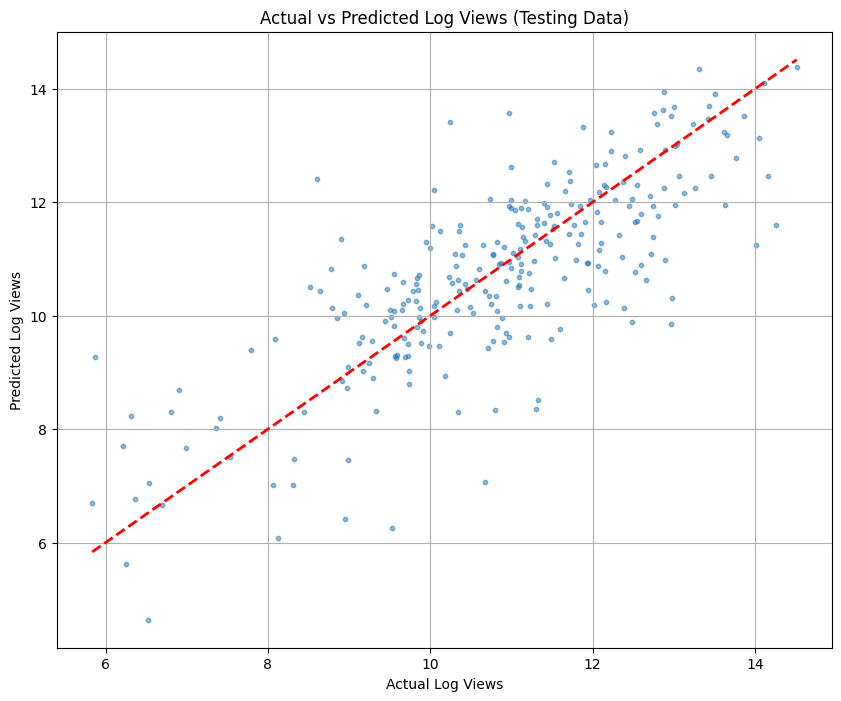

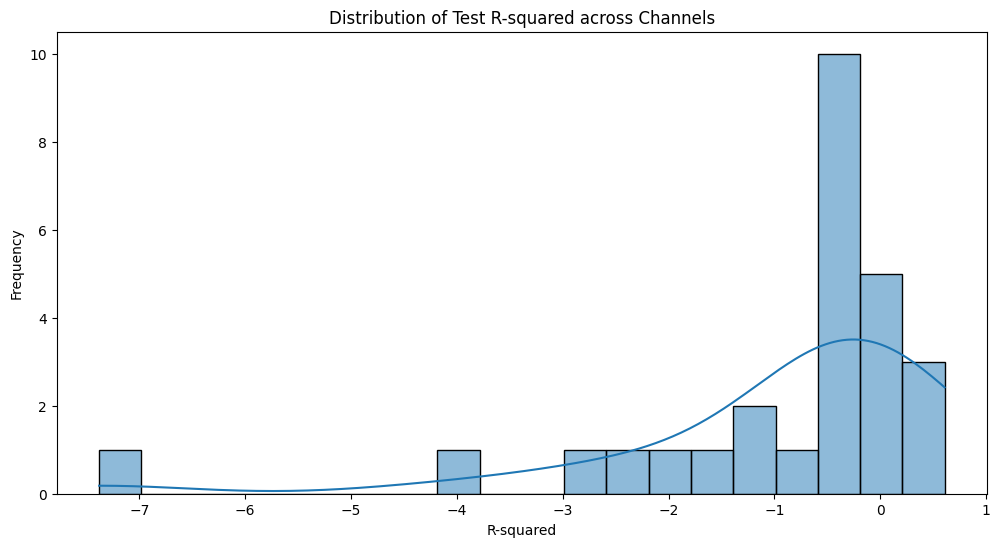

In [75]:
# Visualizing Prediction Performance
plt.figure(figsize=(10, 8))
plt.scatter(all_actual_log_views, all_predicted_log_views, alpha=0.5, s=10)
plt.plot([min(all_actual_log_views), max(all_actual_log_views)],
         [min(all_actual_log_views), max(all_actual_log_views)],
         'r--', lw=2)
plt.title('Actual vs Predicted Log Views (Testing Data)')
plt.xlabel('Actual Log Views')
plt.ylabel('Predicted Log Views')
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
sns.histplot(df_test_summary['test_r2'], bins=20, kde=True)
plt.title('Distribution of Test R-squared across Channels')
plt.xlabel('R-squared')
plt.ylabel('Frequency')
plt.show()

## 8. Expanded Analysis and Debugging

# 1. Global Feature Importance
plt.figure(figsize=(12, 6))
global_coeffs = global_model.params[1:]
global_pvalues = global_model.pvalues[1:]
importance_df = pd.DataFrame({
    'Dimension': [f'Dim_{i+1}' for i in range(CONFIG['GLOBAL_PCA_COMPONENTS'])],
    'Coefficient': global_coeffs,
    'P-Value': global_pvalues
})
importance_df = importance_df.sort_values('Coefficient', key=abs, ascending=False)

sns.barplot(x='Coefficient', y='Dimension', data=importance_df)
plt.title('Global Feature Importance (OLS Coefficients)')
plt.grid(True, axis='x')
plt.show()

print("Top Significant Dimensions (p < 0.05):")
display(importance_df[importance_df['P-Value'] < 0.05])

# 2. Residual Analysis
all_actual_log_views = np.array(all_actual_log_views)
all_predicted_log_views = np.array(all_predicted_log_views)
residuals = all_actual_log_views - all_predicted_log_views

plt.figure(figsize=(10, 6))
plt.scatter(all_predicted_log_views, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Log Views')
plt.ylabel('Residuals')
plt.title('Residual Plot (Checking for Bias)')
plt.grid(True)
plt.show()

# 3. Global vs. Local Weights for top dimensions
local_coeffs_list = []
for summary in training_summaries:
    local_coeffs_list.append(summary['coeffs'])

df_local_coeffs = pd.DataFrame(local_coeffs_list, columns=[f'Dim_{i+1}' for i in selected_dims])
avg_local_coeffs = df_local_coeffs.mean()

comp_df = pd.DataFrame({
    'Global Weight': [global_coeffs[i] for i in selected_dims],
    'Avg Local Weight': avg_local_coeffs.values
}, index=[f'Dim_{i+1}' for i in selected_dims])

comp_df.plot(kind='bar', figsize=(10, 6))
plt.title('Comparison: Global vs. Average Local Dimension Weights')
plt.ylabel('Coefficient Value')
plt.grid(True, axis='y')
plt.show()

# 4. Performance vs. Channel Size
plt.figure(figsize=(10, 6))
plt.scatter(df_train_summary['num_videos'], df_test_summary['test_r2'])
plt.xlabel('Number of Training Videos')
plt.ylabel('Test R2 Score')
plt.title('Channel Size vs. Prediction Accuracy')
plt.grid(True)
plt.show()

# 5. Actual vs Predicted (Denormalized)
plt.figure(figsize=(10, 8))
plt.scatter(all_actual_log_views, all_predicted_log_views, alpha=0.5, s=15)
plt.plot([all_actual_log_views.min(), all_actual_log_views.max()],
         [all_actual_log_views.min(), all_actual_log_views.max()], 'r--')
plt.xlabel('Actual Log Views')
plt.ylabel('Predicted Log Views')
plt.title('Actual vs Predicted Log Views (All test data)')
plt.grid(True)
plt.show()

Mean Absolute Coefficient per Dimension (Global Importance):


,0
Dim_12,2.485114
Dim_4,2.451144
Dim_13,2.441704
Dim_15,2.386212
Dim_10,2.163797
Dim_11,2.039823
Dim_8,1.931541
Dim_14,1.905294
Dim_9,1.821828
Dim_7,1.645671


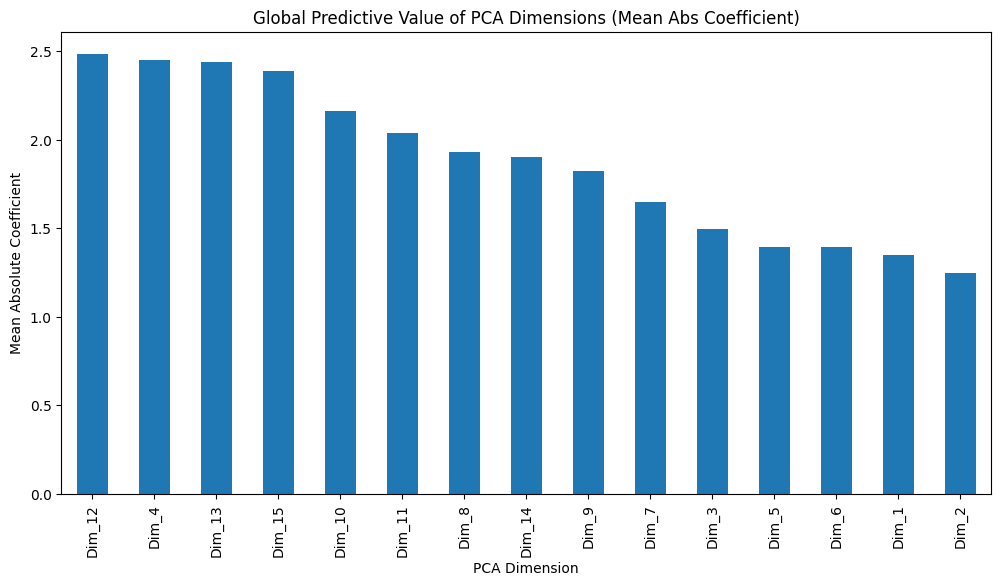

In [76]:
# Aggregating Coefficients across all channel models
all_coefficients = []
for channel_id, model in channel_models.items():
    all_coefficients.append(model.coef_)

df_coeffs = pd.DataFrame(all_coefficients, columns=[f'Dim_{i+1}' for i in range(CONFIG['PCA_COMPONENTS'])])

print('Mean Absolute Coefficient per Dimension (Global Importance):')
mean_abs_coeffs = df_coeffs.abs().mean().sort_values(ascending=False)
display(mean_abs_coeffs)

plt.figure(figsize=(12, 6))
mean_abs_coeffs.plot(kind='bar')
plt.title('Global Predictive Value of PCA Dimensions (Mean Abs Coefficient)')
plt.xlabel('PCA Dimension')
plt.ylabel('Mean Absolute Coefficient')
plt.show()

Dimension with highest coefficient for each channel (Top 10):


,channel_name,top_dimension
0,Bg2 Pod,Dim_1
1,The Prof G Pod – Scott Galloway,Dim_15
2,Asianometry,Dim_5
3,Lenny's Podcast,Dim_14
4,a16z,Dim_6
5,Dan Martell,Dim_13
6,Patrick Boyle,Dim_15
7,Real Vision Presents,Dim_9
8,All-In Podcast,Dim_8
9,Garry Tan,Dim_13


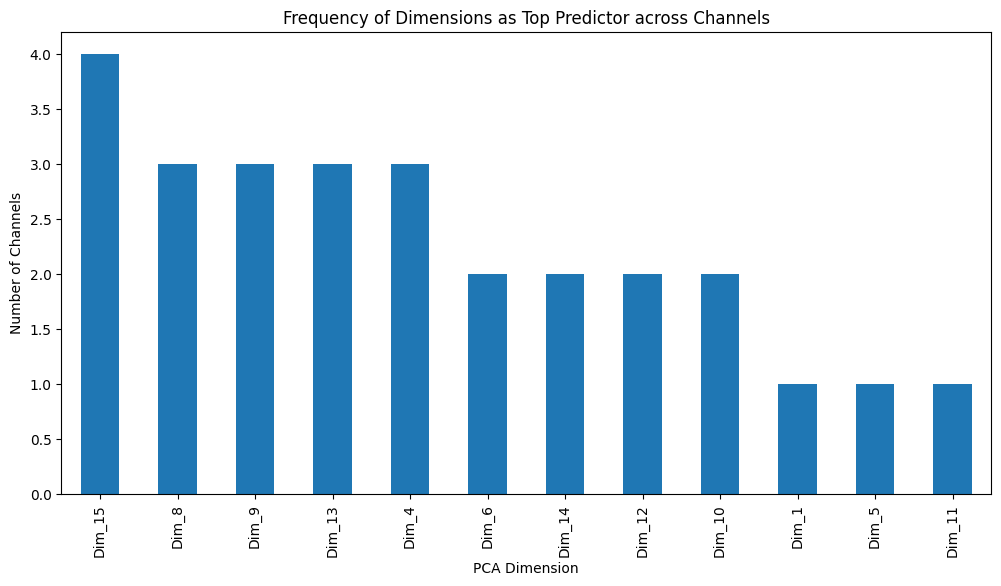

In [77]:
# Per-Channel Dimension Importance
print('Dimension with highest coefficient for each channel (Top 10):')
top_dim_per_channel = df_coeffs.idxmax(axis=1)
df_top_dims = pd.DataFrame({
    'channel_name': [c['channel_name'] for c in train_data],
    'top_dimension': top_dim_per_channel
})
display(df_top_dims.head(10))

plt.figure(figsize=(12, 6))
df_top_dims['top_dimension'].value_counts().plot(kind='bar')
plt.title('Frequency of Dimensions as Top Predictor across Channels')
plt.xlabel('PCA Dimension')
plt.ylabel('Number of Channels')
plt.show()